In [8]:
import numpy as np
import cv2 #import OpenCV
import matplotlib.pyplot as plt

from pathlib import Path

DATA_DIR = Path("/app/data")

In [22]:
img_gray = cv2.imread(str(DATA_DIR / "images/0.jpg"), cv2.IMREAD_GRAYSCALE)
img_color = cv2.imread(str(DATA_DIR / "images/0.jpg"), cv2.IMREAD_COLOR)

In [10]:
print(img_gray.shape)
print(img_color.shape)

(4000, 6000)
(4000, 6000, 3)


In [11]:
print(img_gray[:5, :5])  # un petit coin de 5x5 pixels

[[115 115 115 115 116]
 [115 115 115 115 116]
 [115 115 115 115 116]
 [115 115 115 115 116]
 [115 115 115 115 116]]


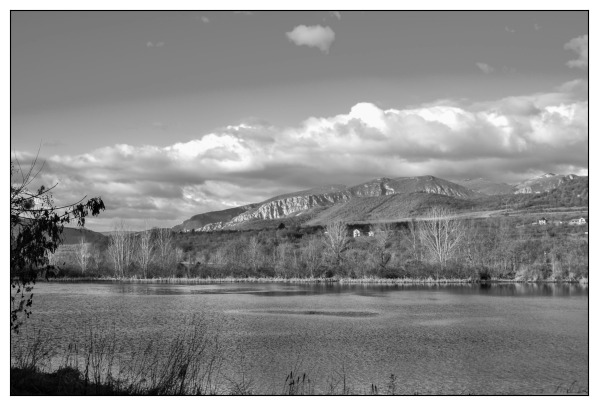

In [12]:
plt.figure(figsize = (8,5))
plt.imshow(img_gray, cmap = 'gray')
plt.xticks([])
plt.yticks([])

plt.show();

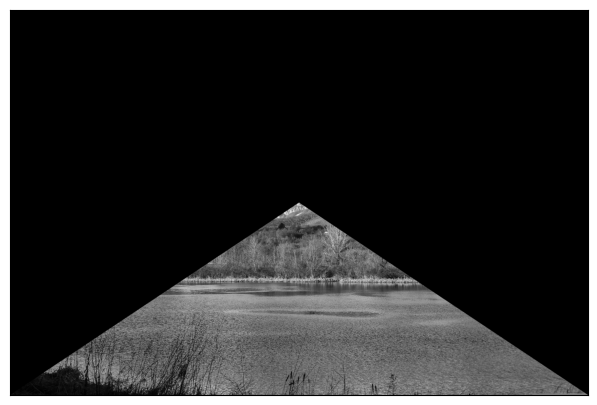

In [14]:
height, width = img_gray.shape[:2] # Ce code récupère la hauteur et la largeur de l'image à partir de son shape
sommets = [
	(0, height), # coin bas-gauche de l'image
	(width / 2, height / 2),	# milieu de l'image (sommet du triangle)
	(width, height),		# coin bas-droite de l'image
]

sommets = np.array([sommets], dtype = np.int32)
mask = np.zeros_like(img_gray)

cv2.fillPoly(mask, sommets, 255)

# la fonction bitwise_and qui permet de sommer deux images d'une certaine manière
# En utilisant la fonction bitwise_and, appliquer le masque à img_gray.
masked_image = cv2.bitwise_and(img_gray, mask)

plt.figure(figsize = (8,5))
plt.imshow(masked_image, cmap = 'gray')
plt.xticks([])
plt.yticks([])
plt.show()

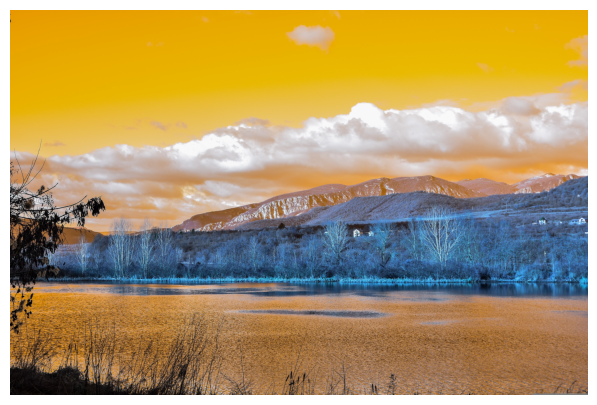

In [18]:
plt.figure(figsize = (8,5))
plt.imshow(img_color)
#plt.xticks([])
#plt.yticks([])
plt.axis('off')
plt.show()

### Les couleurs à l'affichage ne semblent pas naturelles.
##### pyplot utilise l'espace colorimétrique RGB quand cv2 utilise l'espace colorimétrique BGR. Il est donc nécessaire avant d'utiliser imshow, de changer l'espace colorimétrique utilisé pour img_color.
##### grâce à sa fonction cvtColor

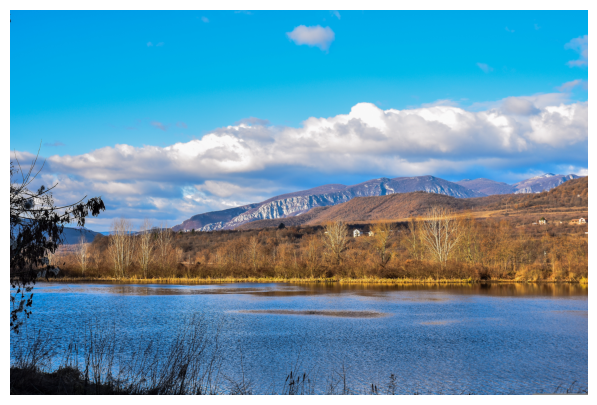

In [24]:
img_color = cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB)
plt.figure(figsize = (8,5))
plt.imshow(img_color)
plt.axis('off')
plt.show()

### cv2 permet également de de diminuer ou d'augmenter la taille de l'image si nécessaire. La fonction resize permet de le faire.
### mon_image = cv2.resize(mon_image, dsize = (150,150))#pour modifier la taille de mon_image en 150 par 150

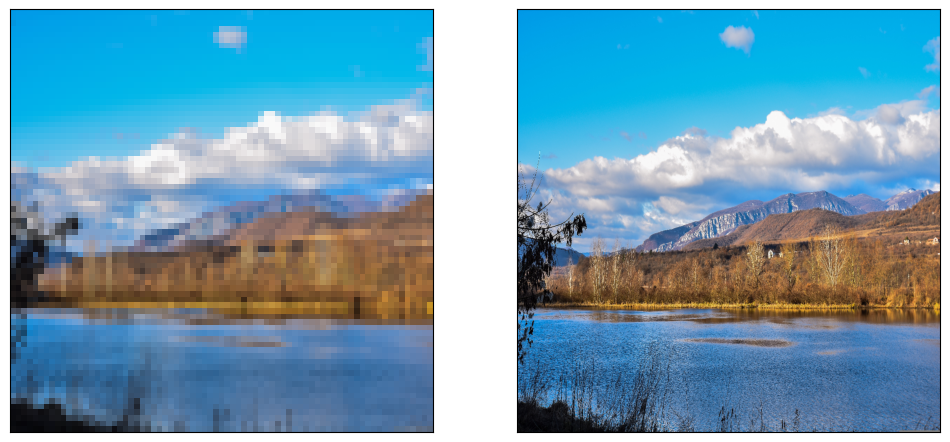

In [25]:
fig = plt.figure(figsize = (12,12))

fig.add_subplot(1,2,1)
plt.imshow(cv2.resize(img_color, dsize = (75,75),interpolation = cv2.INTER_AREA ))
plt.xticks([])
plt.yticks([])

fig.add_subplot(1,2,2)
plt.imshow(cv2.resize(img_color, dsize = (1000,1000)))
plt.xticks([])
plt.yticks([])

plt.show();